
              precision    recall  f1-score   support

not-Atrauman       0.75      1.00      0.86         3
    Atrauman       1.00      0.67      0.80         3

   micro avg       0.83      0.83      0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6
 samples avg       0.83      0.83      0.83         6

Accuracy: 83.33333333333334 %


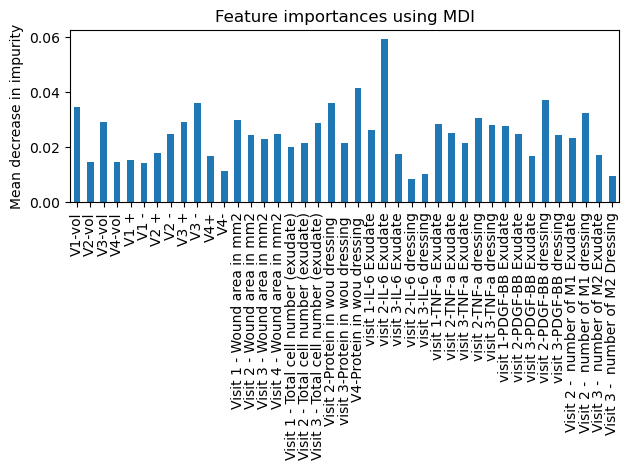

[[0.41781744 0.6074205 ]
 [0.67776793 0.3301339 ]
 [0.7256237  0.25545657]
 [0.84379923 0.16257054]
 [0.27126092 0.7028305 ]
 [0.8068837  0.19513083]]
[[False  True]
 [ True False]
 [ True False]
 [ True False]
 [False  True]
 [ True False]]


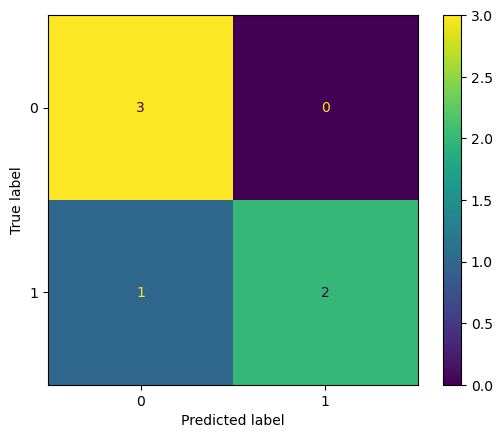

<Figure size 40000x12000 with 0 Axes>

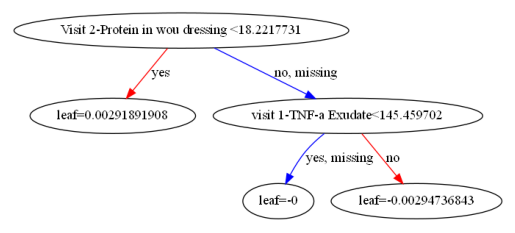

              precision    recall  f1-score   support

 not-Aquacel       1.00      1.00      1.00         3
     Aquacel       1.00      1.00      1.00         8

   micro avg       1.00      1.00      1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11
 samples avg       1.00      1.00      1.00        11

--------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

 not-Aquacel       1.00      1.00      1.00        10
     Aquacel       1.00      1.00      1.00        12

   micro avg       1.00      1.00      1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22
 samples avg       1.00      1.00      1.00        22

--------------------------------------------------------------------------------------------------


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model
from sklearn.ensemble import VotingClassifier

W_tree=2

Treatment=pd.read_csv("../dissertation/Aquacel test_2.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]

R_state=62

X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=R_state,stratify=df_y)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)



clf=XGBClassifier(booster="dart",
                  normalize_type="forest",
                  tree_method="exact",
                  objective="reg:logistic",
                  eta=0.09,
                  max_depth=None,
                  subsample=0.9,
                  colsample_bytree=0.5,
                  colsample_bylevel=0.6,
                  colsample_bynode=0.6,
                  reg_lambda=0.6,
                  reg_alpha=0.7,
                  rate_drop=1,
                  skip_drop=0.5,
                  one_drop=1,
                 #min_child_weight=0,
                  sample_type="weighted",
                  num_parallel_tree=30
                  
    )




clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 


print(classification_report(y_test,y_pred,output_dict=False,target_names=["not-Atrauman","Atrauman"]))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
print(y_pred)

cm = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()

Treatment_test=pd.read_csv("../dissertation/Aquacel test test.csv")
X_test=Treatment_test.iloc[:,1:]
df_y_test=Treatment_test.iloc[:,0]
y_test = to_categorical(df_y_test)

y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 
print(classification_report(y_test,y_pred,output_dict=False,target_names=["not-Aquacel","Aquacel"]))




print("--------------------------------------------------------------------------------------------------")
y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=["not-Aquacel","Aquacel"]))
print("--------------------------------------------------------------------------------------------------")

target = 'key'
class_names=["not-Aquacel ","Aquacel"]


#Which_data=df_y_test
Which_data=df_y

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)

